In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import optuna
from optuna.samplers import TPESampler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam


from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
data = pd.read_excel('regression_avito_deals.xlsx')
data = data.sample(50000, random_state = 42)
data

,item_id,user_id,region,city,parent_category_name,category_name,param_1,param_2,param_3,title,description,price,item_seq_number,activation_date,user_type,deal_probability
279102,7c44a2a9f528,f118b45be716,Татарстан,Казань,Услуги,Предложение услуг,"Ремонт, строительство","Строительство бань, саун",NaN,Банные печи,Банные печи в наличии и под заказ скамейки 1 ...,8000.0,2,2017-03-21,Private,0.20000
332542,64110351080d,ab7907eaf4b3,Ярославская область,Ярославль,Личные вещи,Детская одежда и обувь,Для мальчиков,Обувь,23,Тапки домашние,"Тапки домашние,состояние идеальное",50.0,98,2017-03-25,Private,0.80323
520159,fe4e88136dc1,28a8732f68e1,Башкортостан,Уфа,Личные вещи,Детская одежда и обувь,Для девочек,Обувь,20,Новые кожаные сандалии р.20,"Продам новые кожаные сандалики цвет белый, 12,...",500.0,32,2017-03-16,Private,0.00000
203172,a7fc2797c1f6,e047d821b0ad,Ханты-Мансийский АО,Нижневартовск,Личные вещи,Детская одежда и обувь,Для девочек,Брюки,122-128 см (6-8 лет),Джинсы на девочку,"Продам джинсы очень красиво сидят, но на строй...",500.0,83,2017-03-28,Company,0.00000
475975,b57aeeddd986,5256d8562261,Свердловская область,Екатеринбург,Личные вещи,"Одежда, обувь, аксессуары",Женская одежда,Трикотаж,46–48 (L),Джемпер zolla,"Джемпер zolla/\nразмер L, но маломерка.",400.0,9,2017-03-22,Private,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20683,241a7073714d,c7c5a1b5a073,Алтайский край,Барнаул,Для дома и дачи,Ремонт и строительство,Инструменты,NaN,NaN,Газовый регулятор аргон. CO2,Применяется для аргона и полуавтомата. Торг.,1500.0,10,2017-03-16,Private,0.00000
584790,5be6a0d6ae6b,ffafa8b15b18,Омская область,Омск,Хобби и отдых,Коллекционирование,Другое,NaN,NaN,"Наполеон Хилл ""Каждый человек способен творить...",Книга в хорошем состоянии. Прочитана 1 раз.,50.0,38,2017-03-17,Private,0.00000
283646,ad33b034faef,abf07726d3a5,Татарстан,Казань,Личные вещи,Товары для детей и игрушки,Игрушки,NaN,NaN,Детская Швейная машинка,Новые! в наличии!/\nВозраст: от 3 лет/\nДля де...,950.0,1122,2017-03-21,Shop,0.00000
286716,95727f5306be,3f8ea21e7e2e,Воронежская область,Воронеж,Бытовая электроника,Товары для компьютера,Комплектующие,Видеокарты,NaN,GTS 450 1 GB,"Продам видюху, полностью рабочая и исправна, н...",2000.0,37,2017-03-20,Private,0.23441


In [ ]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,50000,50000,b1bc611c57f9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,50000,45555,45ba3f23bf25,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,50000,28,Краснодарский край,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,1036,Краснодар,2205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category_name,50000,9,Личные вещи,23271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,50000,47,"Одежда, обувь, аксессуары",9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_1,47871,307,Женская одежда,7468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_2,28363,206,Обувь,5053,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_3,21402,499,Вторичка,1634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,50000,37037,Платье,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Missing Values
We will apply the following strategy:
- **Numerical (Price)**: Fill with the median price of the specific category to maintain distribution.
- **Categorical (Params, Description)**: Fill with 'Unknown' or empty strings to allow the models to treat 'missing' as a distinct category.

In [ ]:
# 1. Filling Price with Category Median
data['price'] = data['price'].fillna(data.groupby('category_name')['price'].transform('median'))
# If any are still null (e.g., a category with all nulls), fill with global median
data['price'] = data['price'].fillna(data['price'].median())

# 2. Filling Categorical Parameters
params_cols = ['param_1', 'param_2', 'param_3']
for col in params_cols:
    data[col] = data[col].fillna('Unknown')

# 3. Filling Textual Columns
data['description'] = data['description'].fillna('')

# Check if any nulls remain
data.isnull().sum()

,0
item_id,0
user_id,0
region,0
city,0
parent_category_name,0
category_name,0
param_1,0
param_2,0
param_3,0
title,0


### Feature Engineering
We will create 10 new features:
1. **Activation Weekday**: Day of the week when the ad was posted.
2. **Title Length**: Number of characters in the title.
3. **Description Length**: Number of characters in the description.
4. **Word Count**: Number of words in the description.
5. **Has Price**: Binary flag for missing price.
6. **Price Log**: Log-transformed price to handle skewness.
7. **Price relative to Category**: How much higher/lower the price is compared to the category median.
8. **Is Weekend**: Whether the ad was posted on Saturday or Sunday.
9. **Has Description**: Binary flag if a description exists.
10. **User Ad Count**: Frequency of the `user_id` to represent user activity.

In [ ]:
data['activation_date'] = pd.to_datetime(data['activation_date'])
data['activation_weekday'] = data['activation_date'].dt.weekday
data['is_weekend'] = data['activation_date'].dt.weekday.isin([5, 6]).astype(int)

# 2. Textual Features
data['title_len'] = data['title'].fillna('').apply(len)
data['description_len'] = data['description'].fillna('').apply(len)
data['desc_word_count'] = data['description'].fillna('').apply(lambda x: len(x.split()))
# New Feature 1: Ratio of title length to description length
data['title_desc_len_ratio'] = data['title_len'] / (data['description_len'] + 1)

# 3. Price Features
data['price_log'] = np.log1p(data['price'].fillna(0))

# 4. Statistical/Category Features
# Price compared to category median
category_medians = data.groupby('category_name')['price'].transform('median')
data['price_rel_to_cat'] = data['price'] / (category_medians + 1)

# New Feature 2: Price relative to user's item sequence (bulk vs unique)
data['price_to_seq_ratio'] = data['price_log'] / (np.log1p(data['item_seq_number']))

# 5. User Behavior
data['user_activity_count'] = data.groupby('user_id')['item_id'].transform('count')

# Display new features including replacements
display(data[['activation_weekday', 'is_weekend', 'title_len', 'description_len', 'desc_word_count', 'title_desc_len_ratio', 'price_log', 'price_rel_to_cat', 'price_to_seq_ratio', 'user_activity_count']])

,activation_weekday,is_weekend,title_len,description_len,desc_word_count,title_desc_len_ratio,price_log,price_rel_to_cat,price_to_seq_ratio,user_activity_count
279102,1,0,11,104,18,0.104762,8.987322,15.968064,8.180613,1
332542,5,1,14,34,3,0.400000,3.931826,0.099800,0.855652,2
520159,3,0,27,123,21,0.217742,6.216606,0.998004,1.777947,1
203172,1,0,17,106,18,0.158879,6.216606,0.998004,1.403038,1
475975,2,0,13,38,6,0.333333,5.993961,0.443951,2.603144,1
...,...,...,...,...,...,...,...,...,...,...
20683,3,0,28,44,6,0.622222,7.313887,0.749625,3.050128,1
584790,4,0,50,43,7,1.136364,3.931826,0.075075,1.073225,1
283646,1,0,23,750,112,0.030626,6.857514,0.632911,0.976331,5
286716,0,0,12,100,16,0.118812,7.601402,1.998002,2.089683,1


### Handling High Cardinality: City Column
Instead of dropping the city column, we will group cities that appear less than 50 times into an 'Other' category. This preserves the information for major cities while reducing noise and dimensionality for the Label Encoder.

In [ ]:
# Identify rare cities
city_counts = data['city'].value_counts()
rare_cities = city_counts[city_counts < 130].index

# Group rare cities into 'Other'
data['city'] = data['city'].replace(rare_cities, 'Other')

print(f"Unique cities before grouping: {len(city_counts)}")
print(f"Unique cities after grouping: {data['city'].nunique()}")

Unique cities before grouping: 1036
Unique cities after grouping: 55


### Handling High Cardinality: Param_3
- **param_3**: Grouping rare categories into 'Other' to reduce dimensionality.

In [ ]:
# Group rare values in param_1, param_2, and param_3
for col in ['param_1', 'param_2', 'param_3']:
    counts = data[col].value_counts()
    rare_values = counts[counts < 170].index
    data[col] = data[col].replace(rare_values, 'Other')

In [ ]:
# Drop the unnecessary columns
data =data.drop(['item_id', 'user_id', 'title', 'description', 'activation_date'], axis = 1)

print(f"Unique values in param_3 now: {data['param_3'].nunique()}")

Unique values in param_3 now: 37


In [ ]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
region,50000,28,Краснодарский край,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,55,Other,10738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parent_category_name,50000,9,Личные вещи,23271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,50000,47,"Одежда, обувь, аксессуары",9364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_1,50000,48,Other,8564,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_2,50000,28,Unknown,21637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
param_3,50000,37,Unknown,28598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,50000.0,NaN,NaN,NaN,228903.33679,1674844.112879,0.0,500.0,1300.0,7000.0,195000000.0
item_seq_number,50000.0,NaN,NaN,NaN,737.31506,5501.794802,1.0,9.0,29.0,89.0,204073.0
user_type,50000,3,Private,35706,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Outlier Treatment

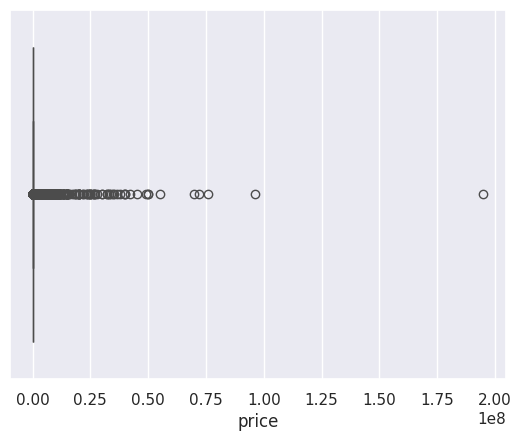

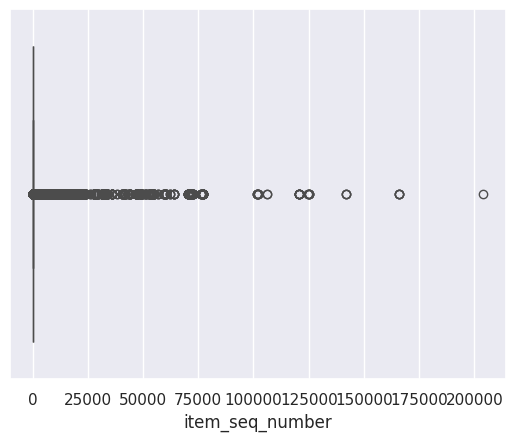

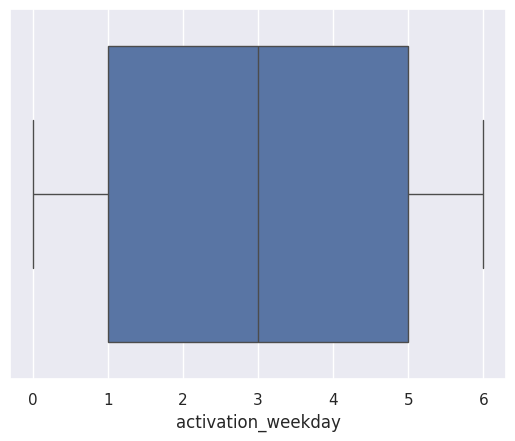

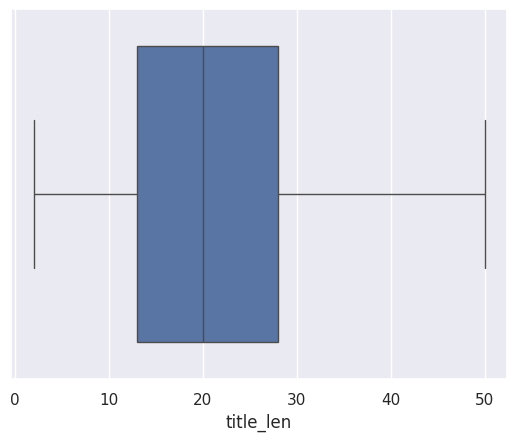

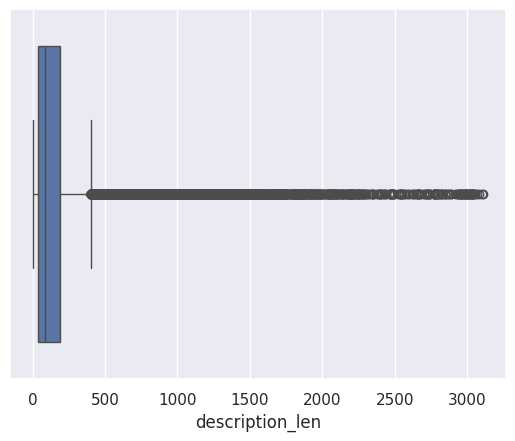

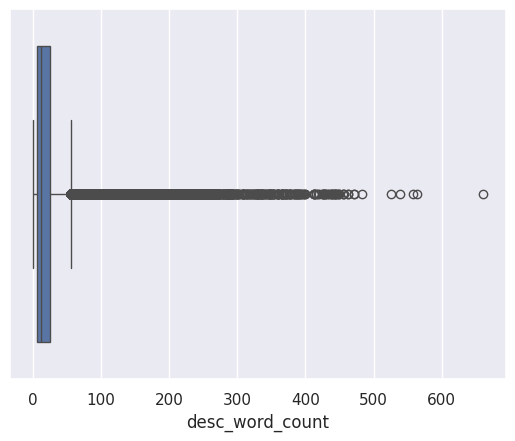

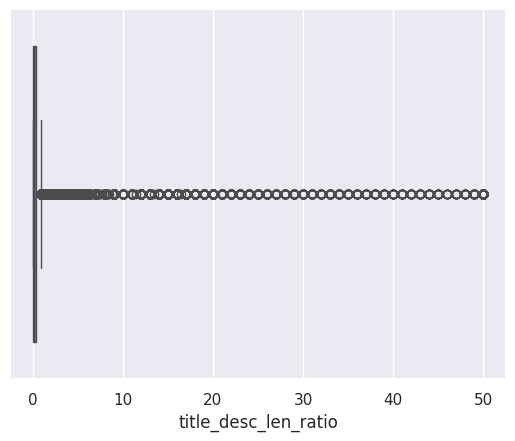

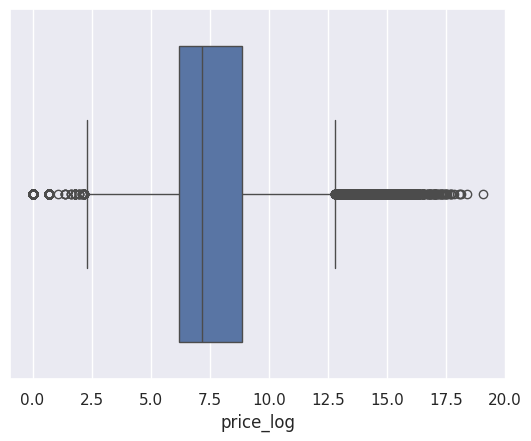

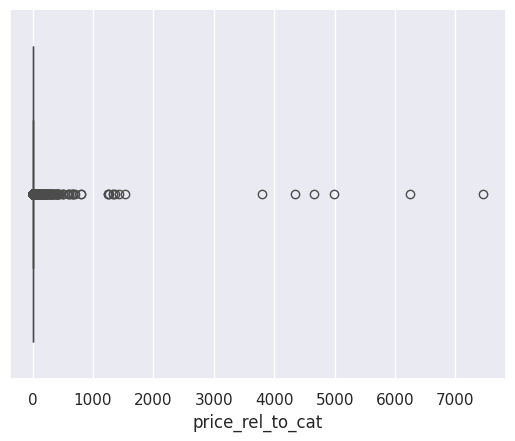

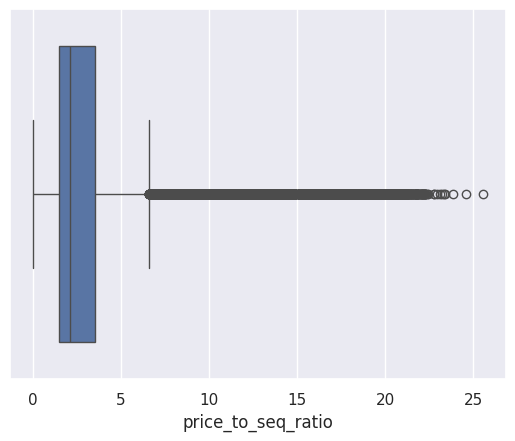

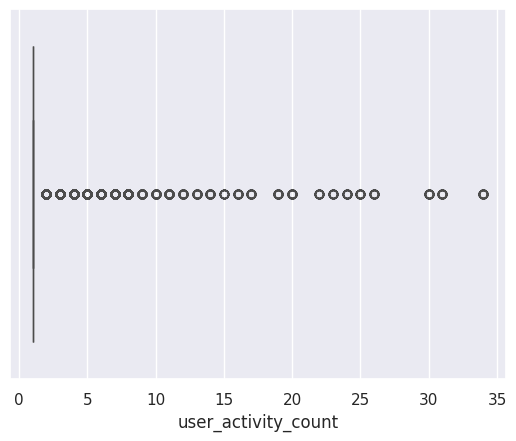

In [ ]:
for i in data.columns:
    if data[i].dtype !=object and data[i].nunique() > 2 and i != 'deal_probability':
        sns.boxplot(data=data,x=data[i])
        plt.show()

In [ ]:
q1=data.quantile(0.25, numeric_only=True)
q3=data.quantile(0.75, numeric_only=True)
IQR=q3-q1

Lower = q1-1.5*IQR
Upper = q3+1.5*IQR

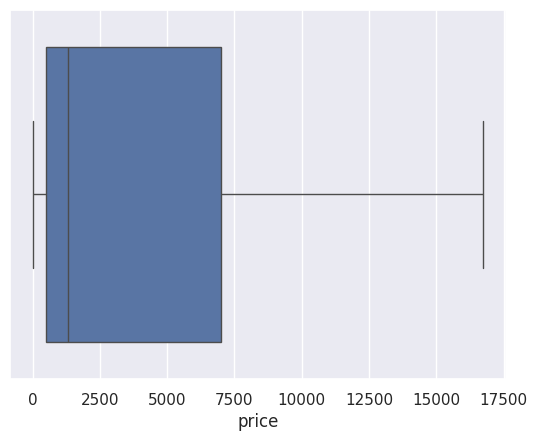

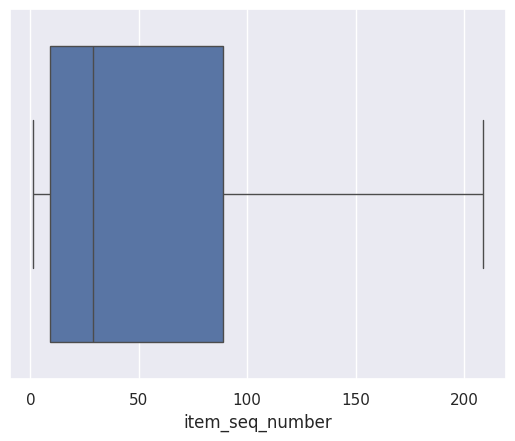

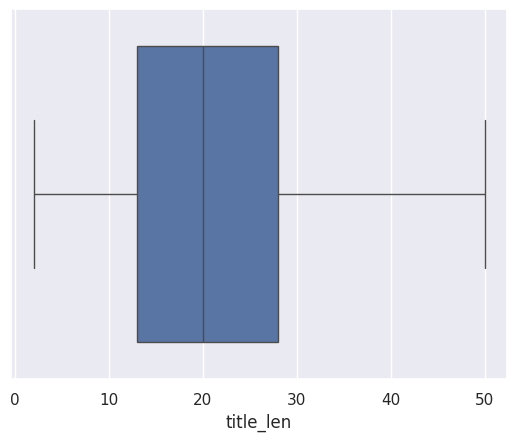

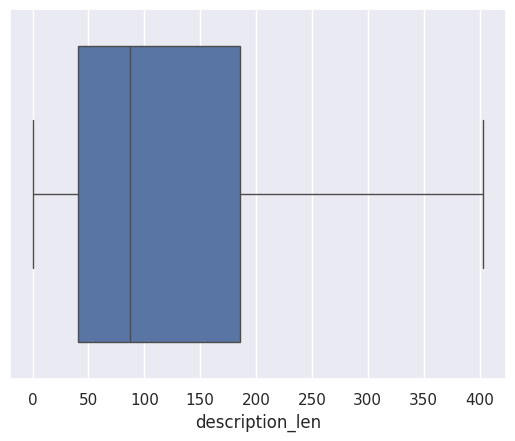

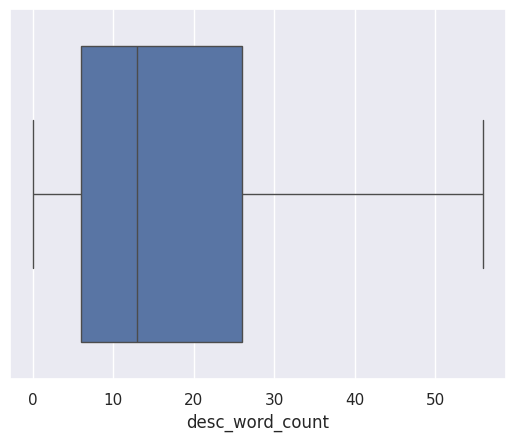

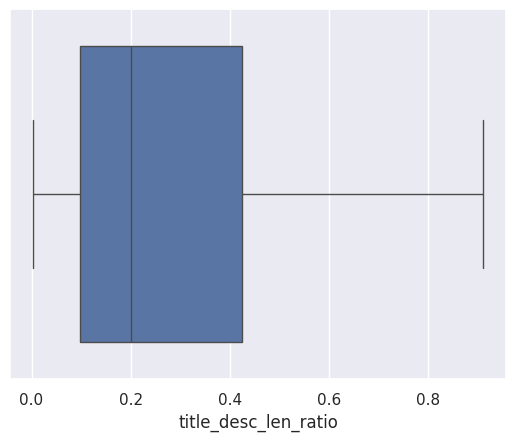

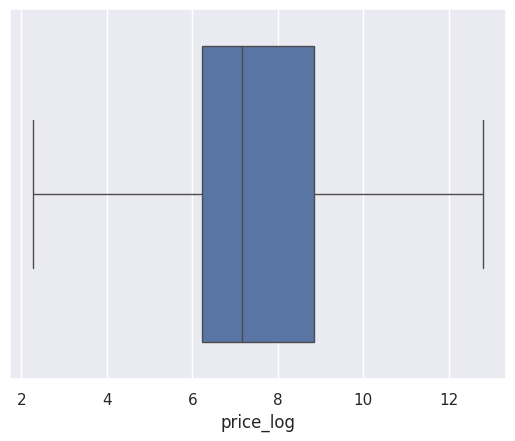

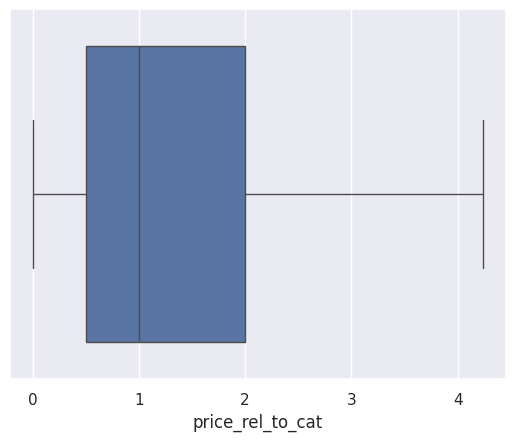

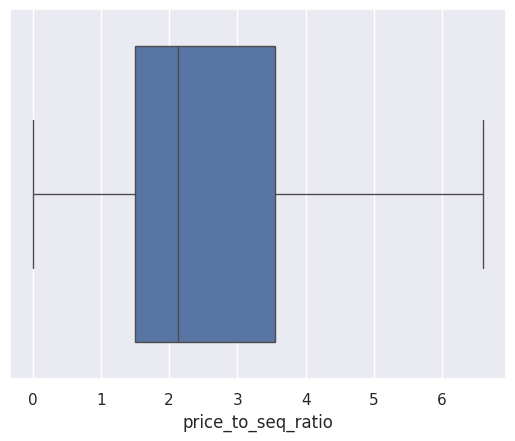

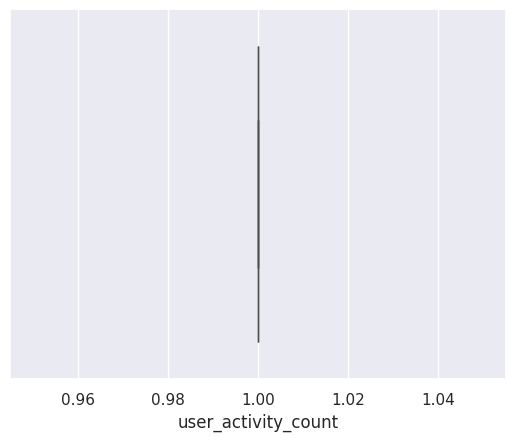

In [ ]:
for i in data.columns:
    if data[i].dtype in [int, float] and data[i].nunique() > 2 and i != 'deal_probability':
        data[i] = np.where(data[i] > Upper[i],Upper[i],data[i])
        data[i] = np.where(data[i] < Lower[i],Lower[i],data[i])
        sns.boxplot(data=data,x=data[i])
        plt.show()

## Categorical Conversion

In [ ]:
for i in data.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  data[i] = le.fit_transform(data[i])

### Scaling and Splitting

In [ ]:
targets = data['deal_probability']

inputs = data.drop(['deal_probability'],axis=1)

In [ ]:
scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,region,city,parent_category_name,category_name,param_1,param_2,param_3,price,item_seq_number,user_type,activation_weekday,is_weekend,title_len,description_len,desc_word_count,title_desc_len_ratio,price_log,price_rel_to_cat,price_to_seq_ratio,user_activity_count
0,0.998613,-0.277433,1.597420,0.820821,1.354370,-0.777984,0.508836,0.512217,-0.838913,0.356177,-0.953572,-0.625373,-0.947693,-0.233368,-0.048107,-0.726652,0.513241,2.215321,2.150493,0.0
1,1.800234,1.812379,0.101848,-0.982320,-0.280100,1.164298,-2.389687,-0.757965,0.511835,0.356177,1.013062,1.599046,-0.675001,-0.792028,-0.907780,0.305932,-1.606310,-1.031566,-1.095556,0.0
2,-1.673455,1.580177,0.101848,-0.982320,-0.513596,1.164298,-2.752003,-0.686067,-0.416804,0.356177,0.029745,-0.625373,0.506666,-0.081731,0.123827,-0.331509,-0.648400,-0.327422,-0.574941,0.0
3,1.533027,0.186970,0.101848,-0.982320,-0.513596,-0.454271,-3.235090,-0.686067,0.300781,-1.629202,-0.953572,-0.625373,-0.402309,-0.217406,-0.048107,-0.537381,-0.648400,-0.327422,-0.786569,0.0
4,0.731406,-0.451584,0.101848,0.445167,-0.046604,2.621009,-0.698882,-0.702045,-0.740421,0.356177,-0.461913,-0.625373,-0.765898,-0.760104,-0.735845,0.072768,-0.741746,-0.761770,-0.109135,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.807058,-1.032087,-0.895199,1.121345,0.264723,-0.616127,0.508836,-0.526296,-0.726351,0.356177,0.029745,-0.625373,0.597564,-0.712219,-0.735845,1.083147,-0.188358,-0.522138,0.143178,0.0
49996,-0.070214,0.593322,2.095944,-0.456404,-0.124436,-0.616127,0.508836,-0.757965,-0.332383,0.356177,0.521404,-0.625373,2.597308,-0.720200,-0.678534,2.098896,-1.606310,-1.050950,-0.972741,0.0
49997,0.998613,-0.277433,0.101848,1.421869,0.109060,-0.616127,0.508836,-0.614170,2.073637,2.341556,-0.953572,-0.625373,0.143076,2.156898,2.129729,-0.985940,-0.379695,-0.613636,-1.027436,0.0
49998,-1.139041,-0.567685,-1.892247,1.572130,0.420387,-0.777984,0.508836,-0.446411,-0.346453,0.356177,-1.445230,-0.625373,-0.856796,-0.265291,-0.162730,-0.677513,-0.067815,0.456523,-0.398973,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

# Modelling

In [ ]:
def create_model(trial):
    # Building artificial neural network
    model = Sequential()

    # First hidden layer
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann_1", 0.1, 0.5)))

    # Second hidden layer
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann_2", 0.1, 0.5)))

    # Output layer
    model.add(Dense(units=1, activation='relu'))

    # Suggest hyperparameters for the optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate, clipvalue=1.0)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate, clipvalue=1.0)

    model.compile(optimizer=optimizer, loss='MAE', metrics=['MAE'])

    return model

In [ ]:
def optimal(trial):

    # Suggest the number of epochs and batch size
    epochs = trial.suggest_int('epochs', 30, 80)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(X_train, y_train, epochs=epochs, callbacks=[early_stop],
                        batch_size=batch_size, verbose=0)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    return r2

study = optuna.create_study(direction='maximize', sampler=TPESampler())
study.optimize(optimal, n_trials=2)

'''
I'm aware that n_trials=2 makes patience=5 redundant but I got highest results with n_trials=2.
That's why I sticked with 2 trials without removing early_stop line.
'''

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-05-26 17:22:50,322] A new study created in memory with name: no-name-8bf7122c-04c4-4d77-af06-908f22101065
/tmp/ipykernel_2726/3228915785.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: MAE,loss
  current = self.get_monitor_value(logs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[I 2026-05-26 17:26:55,204] Trial 0 finished with value: -0.2865985803795401 and parameters: {'epochs': 57, 'batch_size': 21, 'units_layer1': 13, 'dropout_ann_1': 0.11352104061637128, 'units_layer2': 29, 'dropout_ann_2': 0.25400968144158054, 'optimizer': 'sgd', 'learning_rate': 2.5676851105802032e-05}. Best is trial 0 with value: -0.2865985803795401.
/tmp/ipykernel_2726/3228915785.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: MAE,loss
  current = self.get_monitor_value(logs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2026-05-26 17:29:04,452] Trial 1 finished with value: -0.9226700204931095 and parameters: {'epochs': 75, 'batch_size': 57, 'units_layer1': 8, 'dropout_ann_1': 0.19645360344258542, 'units_layer2': 32, 'dropout_ann_2': 0.40163652221388757, 'optimizer': 'adagrad', 'learning_rate': 1.2451317229531789e-05}. Best is trial 0 with value: -0.2865985803795401.


Best trial: -0.2865985803795401
Best hyperparameters: {'epochs': 57, 'batch_size': 21, 'units_layer1': 13, 'dropout_ann_1': 0.11352104061637128, 'units_layer2': 29, 'dropout_ann_2': 0.25400968144158054, 'optimizer': 'sgd', 'learning_rate': 2.5676851105802032e-05}


In [ ]:
best_params = study.best_trial.params

best_params

{'epochs': 57,
 'batch_size': 21,
 'units_layer1': 13,
 'dropout_ann_1': 0.11352104061637128,
 'units_layer2': 29,
 'dropout_ann_2': 0.25400968144158054,
 'optimizer': 'sgd',
 'learning_rate': 2.5676851105802032e-05}

In [ ]:
# Train the final model with the best hyperparameters
best_model = Sequential()

# First hidden layer
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dropout(best_params['dropout_ann_1']))

# Second hidden layer
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dropout(best_params['dropout_ann_2']))

# Output layer
best_model.add(Dense(1, activation='relu'))

In [ ]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'], clipvalue=1.0)
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'], clipvalue=1.0)

In [ ]:
best_model.compile(optimizer=best_optimizer, loss='mae', metrics=['mae'])

In [ ]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])

    '''Predictions for the training set'''

    y_train_pred = model.predict(X_train)

    '''Predictions for the test set'''

    y_test_pred = model.predict(X_test)

    '''Calculate metrics for the training set'''

    r2_train = r2_score(y_train, y_train_pred)


    '''Calculate metrics for the test set'''

    r2_test = r2_score(y_test, y_test_pred)


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'R2': [r2_train * 100, r2_test * 100],

    })

    return results

In [ ]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2518 - mae: 0.2518
Epoch 2/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2274 - mae: 0.2274
Epoch 3/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2098 - mae: 0.2098
Epoch 4/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1967 - mae: 0.1967
Epoch 5/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1851 - mae: 0.1851
Epoch 6/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1787 - mae: 0.1787
Epoch 7/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1736 - mae: 0.1736
Epoch 8/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1674 - mae: 0.1674
Epoch 9/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.1643 - mae: 0.1643
Epoch 10/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1613 - mae: 0.1613
Epoch 11/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1595 - mae: 0.1595
Epoch 12/57
1905/1905 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1567 - mae: 0.1567
E

,Dataset,R2
0,Train,-28.837233
1,Test,-28.663399
